In [122]:
# --- CONFIG ---
REPO_URL = "https://github.com/Yogesh-SN/cobrapy-learning.git"
REPO_NAME = "cobrapy-learning"
BRANCH = "main"

# --- SETUP ---
import os
import sys

if os.path.exists(REPO_NAME):
    print("Repo exists → pulling latest changes...")
    %cd $REPO_NAME
    !git fetch origin
    !git reset --hard origin/$BRANCH
    !git clean -fd
else:
    print("Cloning fresh repo...")
    !git clone $REPO_URL
    %cd $REPO_NAME

# --- INSTALL DEPENDENCIES ---
if os.path.exists("requirements.txt"):
    !pip install -r requirements.txt

# --- FIX IMPORT PATH ---
SRC_PATH = os.path.abspath("src")
if SRC_PATH not in sys.path:
    sys.path.append(SRC_PATH)

print("Setup complete. Current dir:", os.getcwd())

Repo exists → pulling latest changes...
/content/cobrapy-learning/cobrapy-learning/cobrapy-learning
HEAD is now at d26f7b9 Updated m9_media variables
Setup complete. Current dir: /content/cobrapy-learning/cobrapy-learning/cobrapy-learning


In [123]:
!git log -1
!ls src
import helpers
print(helpers.__file__)

commit d26f7b91c873461e8427261e33d29199ccfd6467 (HEAD -> main, origin/main, origin/HEAD)
Author: Yogesh-SN <yogeshnegi987@gmail.com>
Date:   Fri Jun 12 20:50:11 2026 +0530

    Updated m9_media variables
helpers.py  main_work.py  __pycache__
/content/cobrapy-learning/src/helpers.py


In [124]:
import importlib
import helpers

importlib.reload(helpers)

<module 'helpers' from '/content/cobrapy-learning/src/helpers.py'>

In [125]:
from helpers import load_model, m9_media

In [126]:
model = load_model('models/e_coli_core.xml')

In [127]:
model.medium #This is the minimal media only; atleast the components of it.

{'EX_co2_e': 1000.0,
 'EX_glc__D_e': 10.0,
 'EX_h_e': 1000.0,
 'EX_h2o_e': 1000.0,
 'EX_nh4_e': 1000.0,
 'EX_o2_e': 1000.0,
 'EX_pi_e': 1000.0}

In [128]:
for r in model.reactions: #All exchange reactions in the e_coli_core model
  if 'EX' in r.id:
    print(r)

EX_ac_e: ac_e --> 
EX_acald_e: acald_e --> 
EX_akg_e: akg_e --> 
EX_co2_e: co2_e <=> 
EX_etoh_e: etoh_e --> 
EX_for_e: for_e --> 
EX_fru_e: fru_e --> 
EX_fum_e: fum_e --> 
EX_glc__D_e: glc__D_e <=> 
EX_gln__L_e: gln__L_e --> 
EX_glu__L_e: glu__L_e --> 
EX_h_e: h_e <=> 
EX_h2o_e: h2o_e <=> 
EX_lac__D_e: lac__D_e --> 
EX_mal__L_e: mal__L_e --> 
EX_nh4_e: nh4_e <=> 
EX_o2_e: o2_e <=> 
EX_pi_e: pi_e <=> 
EX_pyr_e: pyr_e --> 
EX_succ_e: succ_e --> 


In [129]:
l = []
with model:
    #print(model.slim_optimize())
    medium = model.medium
    for i in range(0,51,5):
      #print(float(i))
      medium["EX_o2_e"] = float(i)
      model.medium = medium
      growth_rate = model.slim_optimize()
      l.append((float(i),round(growth_rate,3)))
      #print(model.slim_optimize())

print(l)
# outside : original medium restored automatically

[(0.0, 0.212), (5.0, 0.392), (10.0, 0.559), (15.0, 0.718), (20.0, 0.833), (25.0, 0.874), (30.0, 0.874), (35.0, 0.874), (40.0, 0.874), (45.0, 0.874), (50.0, 0.874)]


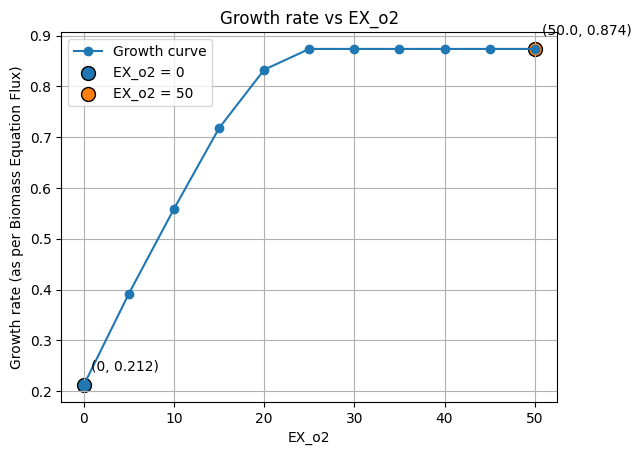

In [130]:
import matplotlib.pyplot as plt

x, y = zip(*l)

plt.plot(x, y, marker='o', label="Growth curve")

x0, y0 = l[0]
plt.scatter(x0, y0, s=100, edgecolors='black', label="EX_o2 = 0")
plt.annotate(f"(0, {y0:.3f})", (x0, y0), textcoords="offset points", xytext=(5,10))

xn, yn = l[-1]
plt.scatter(xn, yn, s=100, edgecolors='black', label="EX_o2 = 50")
plt.annotate(f"({xn}, {yn:.3f})", (xn, yn),textcoords="offset points", xytext=(5,10))

plt.xlabel("EX_o2")
plt.ylabel("Growth rate (as per Biomass Equation Flux)")
plt.title("Growth rate vs EX_o2")
plt.grid(True)
plt.legend()

plt.show()

In [131]:
with model:
    base_medium = model.medium.copy()

    # AEROBIC
    medium = base_medium.copy()
    model.medium = medium

    sol_aero = model.optimize()
    print("=== AEROBIC (Top 10 Fluxes) ===")

    top_aero = sol_aero.fluxes.sort_values(ascending=False).head(10)

    for rxn_id, flux in top_aero.items():
        rxn = model.reactions.get_by_id(rxn_id)
        print(f"{rxn_id}: {rxn.reaction} -> {flux:.3f}")

    print(f"\nAerobic Growth Rate: {sol_aero.objective_value:.4f}\n")

    # ANAEROBIC

    medium = base_medium.copy()
    medium["EX_o2_e"] = 0
    model.medium = medium

    sol_ana = model.optimize()
    print("=== ANAEROBIC (Top 10 Fluxes) ===")

    top_ana = sol_ana.fluxes.sort_values(ascending=False).head(10)

    for rxn_id, flux in top_ana.items():
        rxn = model.reactions.get_by_id(rxn_id)
        print(f"{rxn_id}: {rxn.reaction} -> {flux:.3f}")

    print(f"\nAnaerobic Growth Rate: {sol_ana.objective_value:.4f}\n")

=== AEROBIC (Top 10 Fluxes) ===
ATPS4r: adp_c + 4.0 h_e + pi_c <=> atp_c + h2o_c + 3.0 h_c -> 45.514
CYTBD: 2.0 h_c + 0.5 o2_c + q8h2_c --> h2o_c + 2.0 h_e + q8_c -> 43.599
NADH16: 4.0 h_c + nadh_c + q8_c --> 3.0 h_e + nad_c + q8h2_c -> 38.535
EX_h2o_e: h2o_e <=>  -> 29.176
EX_co2_e: co2_e <=>  -> 22.810
O2t: o2_e <=> o2_c -> 21.799
EX_h_e: h_e <=>  -> 17.531
GAPD: g3p_c + nad_c + pi_c <=> 13dpg_c + h_c + nadh_c -> 16.024
ENO: 2pg_c <=> h2o_c + pep_c -> 14.716
GLCpts: glc__D_e + pep_c --> g6p_c + pyr_c -> 10.000

Aerobic Growth Rate: 0.8739

=== ANAEROBIC (Top 10 Fluxes) ===
EX_h_e: h_e <=>  -> 30.554
GAPD: g3p_c + nad_c + pi_c <=> 13dpg_c + h_c + nadh_c -> 19.437
ENO: 2pg_c <=> h2o_c + pep_c -> 19.121
EX_for_e: for_e -->  -> 17.805
PFL: coa_c + pyr_c --> accoa_c + for_c -> 17.805
GLCpts: glc__D_e + pep_c --> g6p_c + pyr_c -> 10.000
PGI: g6p_c <=> f6p_c -> 9.957
FBA: fdp_c <=> dhap_c + g3p_c -> 9.789
TPI: dhap_c <=> g3p_c -> 9.789
PFK: atp_c + f6p_c --> adp_c + fdp_c + h_c -> 9.789

An

In [132]:
carbon_source = ['EX_ac_e','EX_glc__D_e','EX_etoh_e', 'EX_fru_e','EX_lac__D_e','EX_mal__L_e','EX_pyr_e','EX_succ_e']

l1 = []

base_medium = model.medium.copy()

for carbon in carbon_source:
    with model:
        medium = base_medium.copy()

        # turn OFF all carbon sources first
        for c in carbon_source:
            medium[c] = 0

        # turn ON only the current one
        medium[carbon] = 10

        model.medium = medium

        growth_rate = model.slim_optimize()

        l1.append((carbon, round(growth_rate, 3)))

        print(f"Carbon source: {carbon}")
        print(f"Growth rate: {growth_rate}")
        print(f"Medium: {model.medium}\n")

print(l1)
# outside → original medium restored automatically

Carbon source: EX_ac_e
Growth rate: 0.17333858447778647
Medium: {'EX_ac_e': 10, 'EX_co2_e': 1000.0, 'EX_h_e': 1000.0, 'EX_h2o_e': 1000.0, 'EX_nh4_e': 1000.0, 'EX_o2_e': 1000.0, 'EX_pi_e': 1000.0}

Carbon source: EX_glc__D_e
Growth rate: 0.8739215069684302
Medium: {'EX_co2_e': 1000.0, 'EX_glc__D_e': 10.0, 'EX_h_e': 1000.0, 'EX_h2o_e': 1000.0, 'EX_nh4_e': 1000.0, 'EX_o2_e': 1000.0, 'EX_pi_e': 1000.0}

Carbon source: EX_etoh_e
Growth rate: 0.3304198006407222
Medium: {'EX_co2_e': 1000.0, 'EX_etoh_e': 10, 'EX_h_e': 1000.0, 'EX_h2o_e': 1000.0, 'EX_nh4_e': 1000.0, 'EX_o2_e': 1000.0, 'EX_pi_e': 1000.0}

Carbon source: EX_fru_e
Growth rate: 0.8739215069684306
Medium: {'EX_co2_e': 1000.0, 'EX_fru_e': 10, 'EX_h_e': 1000.0, 'EX_h2o_e': 1000.0, 'EX_nh4_e': 1000.0, 'EX_o2_e': 1000.0, 'EX_pi_e': 1000.0}

Carbon source: EX_lac__D_e
Growth rate: 0.3503111250607409
Medium: {'EX_co2_e': 1000.0, 'EX_h_e': 1000.0, 'EX_h2o_e': 1000.0, 'EX_lac__D_e': 10, 'EX_nh4_e': 1000.0, 'EX_o2_e': 1000.0, 'EX_pi_e': 1000

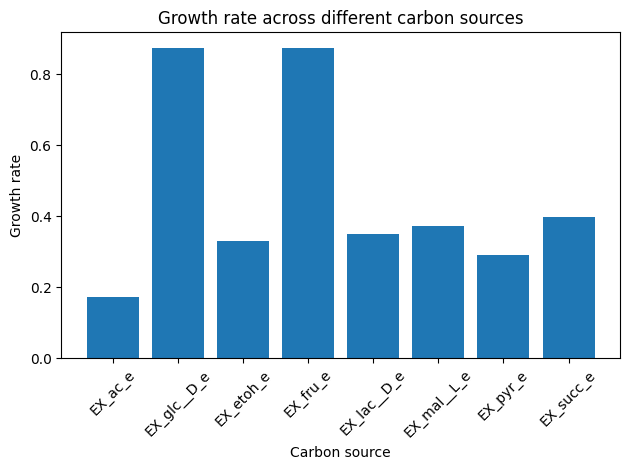

In [133]:
carbon_sources = [c for c, g in l1]
growth_rates = [g for c, g in l1]

plt.figure()
plt.bar(carbon_sources, growth_rates)

plt.xlabel("Carbon source")
plt.ylabel("Growth rate")
plt.title("Growth rate across different carbon sources")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()